In [1]:
# %%
# Data Handling
import pandas as pd
import numpy as np
import os

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Set a random state for reproducibility
random_state = 42

In [2]:
# ## 📂 Load Data (Clinical & Methylation)

# %%
# Set base path
base_path = "/Users/nijat/Downloads/OneDrive_1_2024-09-21/Data"

# Load Clinical Data
clinical_data_path = os.path.join(base_path, "2019_TCGA-CDR-SupplementalTableS1.xlsx")
main_data_df = pd.read_excel(clinical_data_path)

# Load Tumor Classification Data
new_labels_path = os.path.join(base_path, "Matrix_WHO2021.csv")
new_categories = pd.read_csv(new_labels_path)

# Load Methylation Data (GBM & LGG)
gbm_data = pd.read_csv(os.path.join(base_path, "GBM_450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"))
lgg_data = pd.read_csv(os.path.join(base_path, "LGG-450K_Filtered_X-Y,SNPs,Non-overlap850K.csv"))

print("✅ Data Loaded Successfully!")

✅ Data Loaded Successfully!


In [3]:
# ## 🔍 Preprocess & Merge Data

# %%
# Rename column for consistency
main_data_df.rename(columns={'bcr_patient_barcode': 'Patient_ID'}, inplace=True)

# Filter Clinical Data for GBM & LGG tumor types
filtered_data_df = main_data_df[main_data_df['type'].isin(['GBM', 'LGG'])]

# Merge Clinical and Tumor Classification Data
merged_clinical_data = pd.merge(filtered_data_df, new_categories, on='Patient_ID', how='inner')

print(f"✅ Merged Clinical Data Shape: {merged_clinical_data.shape}")

# %%
# Function to preprocess methylation data (Transpose & Rename)
def preprocess_methylation_data(df):
    df_trns = df.T  # Transpose data (genes as columns)
    df_trns.columns = df_trns.iloc[0]  # First row as column names
    return df_trns[1:]  # Remove first row

# Process GBM & LGG Data
gbm_trns_final = preprocess_methylation_data(gbm_data)
lgg_trns_final = preprocess_methylation_data(lgg_data)

# Merge GBM & LGG Methylation Data
merged_methylation_data = pd.concat([gbm_trns_final, lgg_trns_final])

# Ensure "Patient_ID" is named correctly
merged_methylation_data.rename(columns={'Index': 'Patient_ID'}, inplace=True)

# Merge Methylation & Clinical Data
final_data = pd.merge(merged_methylation_data, merged_clinical_data, 
                      left_index=True, right_on='Patient_ID', 
                      how='inner')

print(f"✅ Final Merged Data Shape: {final_data.shape}")

✅ Merged Clinical Data Shape: (1110, 37)
✅ Final Merged Data Shape: (653, 403991)


In [4]:
# Define survival-related columns and cancer type column
survival_columns = ['OS', 'OS.time', 'DSS', 'DSS.time', 'PFI', 'PFI.time']
target_col = 'classification.2021_simplified.labels'  # Cancer type

# Define selected probe columns
selected_probes = [
    'cg23609985', 'cg03609308', 'cg22304169', 'cg02483271', 'cg00339300',
    'cg20326704', 'cg26146617', 'cg27255678', 'cg04779720', 'cg10902825',
    'cg08535928', 'cg20629587', 'cg05976753', 'cg12163952', 'cg24934561',
    'cg25604994', 'cg08409074', 'cg01873236', 'cg00090619', 'cg18943693',
    'cg20564913', 'cg12869912', 'cg12621315', 'cg17213402', 'cg22230604',
    'cg13999415', 'cg15472784', 'cg02864688', 'cg12630147', 'cg10706230',
    'cg20276103', 'cg04770813', 'cg03962809', 'cg19093820', 'cg24284369',
    'cg03505995', 'cg25467973', 'cg20532370', 'cg14453978', 'cg13586420',
    'cg25503044', 'cg20732367', 'cg18108087', 'cg08090640', 'cg08414647',
    'cg17393296', 'cg07893801', 'cg14640066', 'cg25653638', 'cg21195256',
    'cg05903444', 'cg26073416', 'cg17895157', 'cg01660911', 'cg12210255',
    'cg04437966', 'cg09219721', 'cg01813033', 'cg15752043', 'cg14030586',
    'cg14905632', 'cg04951819', 'cg01547541', 'cg26694713', 'cg18875371',
    'cg19490297', 'cg24081688', 'cg02103647', 'cg24597705', 'cg07482935'
]

# Ensure only existing survival-related and probe columns are kept
columns_to_keep = list(set(survival_columns) & set(final_data.columns)) + [target_col]
probe_columns_to_keep = list(set(selected_probes) & set(final_data.columns))

# Create survival_df with survival data, selected probes, and cancer type
survival_df = final_data[columns_to_keep + probe_columns_to_keep].dropna()

# Explicitly select these three cancer types
selected_cancer_types = ['glioblastoma', 'astrocytoma', 'oligodendroglioma']

# Filter dataset to include only these 3 cancer types
survival_df = survival_df[survival_df[target_col].isin(selected_cancer_types)]

print(f"✅ Survival Data Shape: {survival_df.shape}")
print(f"✅ Cancer Types Included: {survival_df[target_col].unique().tolist()}")
print(f"✅ Selected Probe Columns Retained: {len(probe_columns_to_keep)}")


✅ Survival Data Shape: (602, 77)
✅ Cancer Types Included: ['glioblastoma', 'astrocytoma', 'oligodendroglioma']
✅ Selected Probe Columns Retained: 70


In [5]:
print(f"✅ Cancer Types Included: {survival_df[target_col].unique().tolist()}")


✅ Cancer Types Included: ['glioblastoma', 'astrocytoma', 'oligodendroglioma']


In [6]:
survival_df.columns

Index(['DSS.time', 'PFI.time', 'PFI', 'DSS', 'OS.time', 'OS',
       'classification.2021_simplified.labels', 'cg01660911', 'cg12630147',
       'cg17393296', 'cg09219721', 'cg20276103', 'cg08535928', 'cg01873236',
       'cg18108087', 'cg07893801', 'cg27255678', 'cg20629587', 'cg05903444',
       'cg21195256', 'cg15752043', 'cg14905632', 'cg04770813', 'cg04437966',
       'cg23609985', 'cg04951819', 'cg22304169', 'cg25503044', 'cg07482935',
       'cg13586420', 'cg20732367', 'cg03505995', 'cg24284369', 'cg24934561',
       'cg19093820', 'cg12621315', 'cg22230604', 'cg04779720', 'cg02864688',
       'cg01813033', 'cg25467973', 'cg12163952', 'cg12869912', 'cg00339300',
       'cg14640066', 'cg25653638', 'cg03609308', 'cg15472784', 'cg03962809',
       'cg10706230', 'cg13999415', 'cg25604994', 'cg14030586', 'cg18943693',
       'cg01547541', 'cg20326704', 'cg26694713', 'cg26073416', 'cg02103647',
       'cg24597705', 'cg26146617', 'cg00090619', 'cg20532370', 'cg05976753',
       'cg14453

In [7]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# from sklearn.preprocessing import LabelEncoder

# # Define features (probe columns) and target (cancer type)
# probe_columns = [col for col in survival_df.columns if col.startswith('cg')]
# target_col = 'classification.2021_simplified.labels'

# # Encode target labels
# label_encoder = LabelEncoder()
# survival_df[target_col] = label_encoder.fit_transform(survival_df[target_col])

# # Split the data into training and testing sets
# X = survival_df[probe_columns]
# y = survival_df[target_col]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Train a simple classification model (Random Forest)
# clf = RandomForestClassifier(n_estimators=100, random_state=42)
# clf.fit(X_train, y_train)

# # Predict on the test set
# y_pred = clf.predict(X_test)

# # Compute performance metrics
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred, average='macro')  # Macro-averaging for multiple classes
# recall = recall_score(y_test, y_pred, average='macro')
# f1 = f1_score(y_test, y_pred, average='macro')

# # Convert encoded labels back to original class names as strings
# target_names = [str(label) for label in label_encoder.inverse_transform(sorted(set(y_test)))]

# # Generate classification report
# classification_rep = classification_report(y_test, y_pred, target_names=target_names)

# # Display results
# print(f"✅ Accuracy: {accuracy:.5f}")
# print(f"✅ Precision: {precision:.5f}")
# print(f"✅ Recall: {recall:.5f}")
# print(f"✅ F1 Score: {f1:.5f}")
# print("\n🔹 Classification Report:\n", classification_rep)


In [8]:
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from xgboost import XGBClassifier
# from sklearn.svm import SVC
# from sklearn.model_selection import cross_val_score, StratifiedKFold

# # Ensure X contains only numeric values
# X = X.astype(float)

# # Define classifiers
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
#     "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
#     "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
#     "SVM": SVC(kernel="linear", probability=True, random_state=42)
# }

# # Perform cross-validation for each model
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# model_names = []
# mean_accuracies = []
# std_accuracies = []

# for name, model in models.items():
#     scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
#     model_names.append(name)
#     mean_accuracies.append(scores.mean())
#     std_accuracies.append(scores.std())
#     print(f"✅ {name} - Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# # Plot results
# plt.figure(figsize=(10, 6))
# plt.barh(model_names, mean_accuracies, xerr=std_accuracies, color='blue', alpha=0.7, capsize=5)
# plt.xlabel("Mean Accuracy (± Std Dev)")
# plt.ylabel("Model")
# plt.title("Model Performance Comparison")
# plt.xlim(0.8, 1.02)
# plt.grid(axis="x", linestyle="--", alpha=0.6)
# plt.show()


In [9]:
# Ensure final_data exists
if 'final_data' not in locals():
    raise NameError("⚠️ final_data is not defined. Please ensure it has been created.")

# Define survival-related columns and target column
survival_columns = ['OS.time', 'DSS.time', 'PFI.time', 'OS', 'DSS', 'PFI']
target_col = 'classification.2021_simplified.labels'

# Keep only relevant survival and target columns
existing_survival_columns = [col for col in survival_columns if col in survival_df.columns]
survival = survival_df[existing_survival_columns + [target_col]].dropna()

print(f"✅ survival_df reloaded with shape: {survival_df.shape}")


✅ survival_df reloaded with shape: (602, 77)


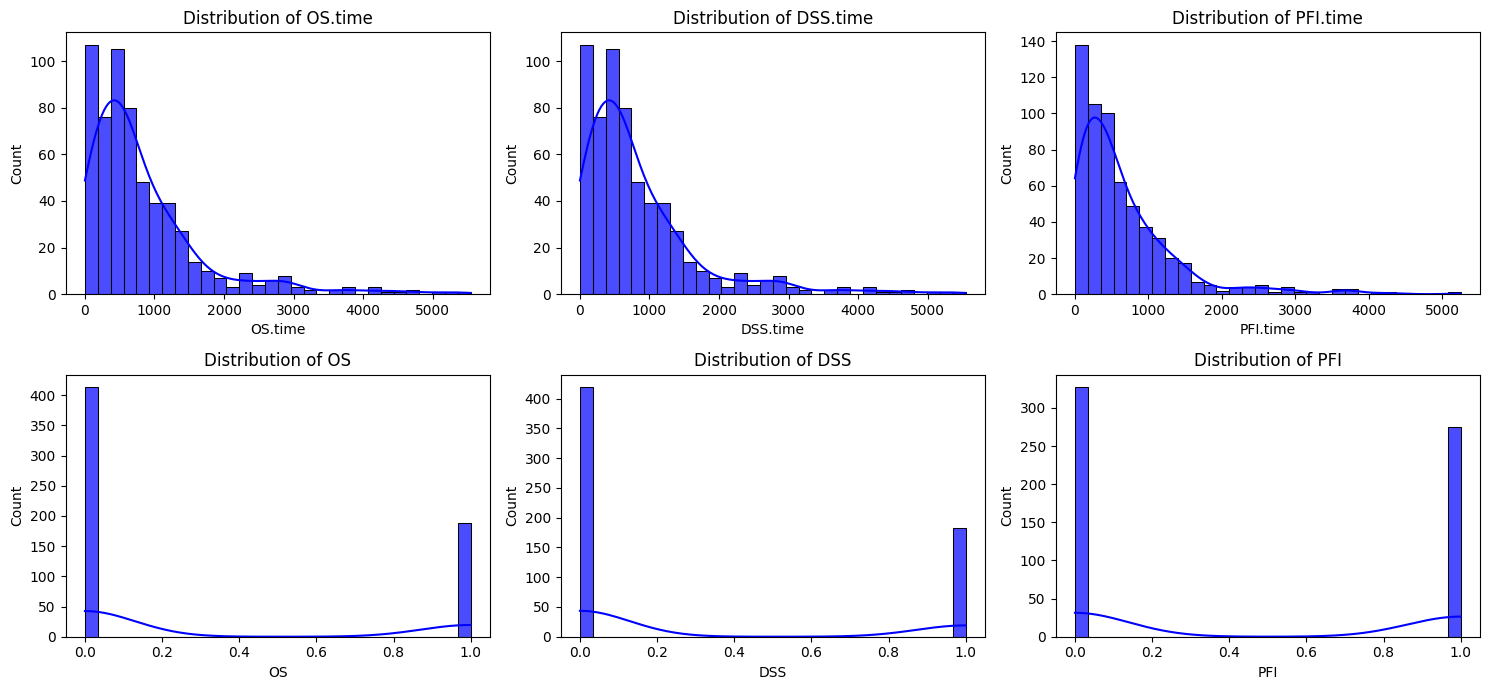

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure
num_cols = len(existing_survival_columns)
plt.figure(figsize=(15, 7))

# Plot each column's distribution
for i, col in enumerate(existing_survival_columns, 1):
    plt.subplot(2, (num_cols + 1) // 2, i)
    sns.histplot(survival_df[col], bins=30, kde=True, color='blue', alpha=0.7)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


In [11]:
time_columns = ['OS.time', 'DSS.time', 'PFI.time']
time_ranges = survival_df[time_columns].agg(['min', 'max'])
print(time_ranges)

     OS.time  DSS.time  PFI.time
min      0.0       0.0       0.0
max   5546.0    5546.0    5255.0


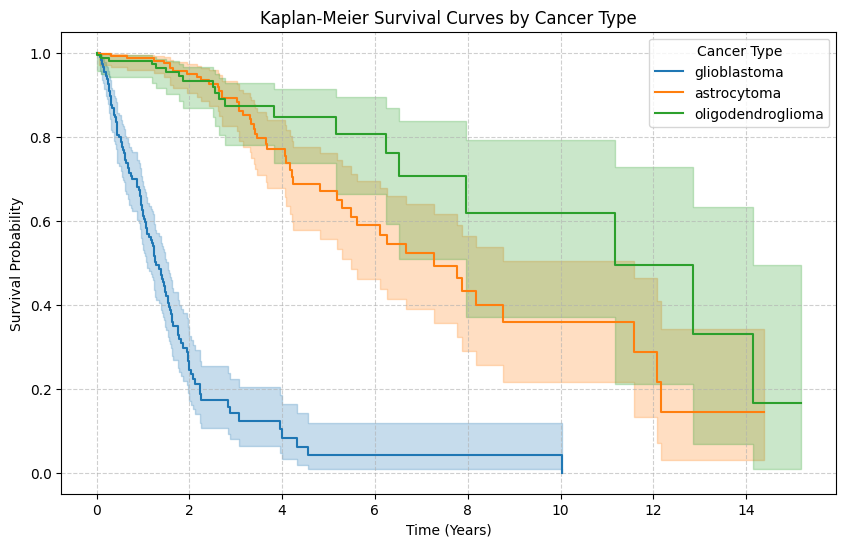

In [12]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Ensure survival_df has necessary columns
required_columns = ['OS.time', 'OS', 'classification.2021_simplified.labels']
for col in required_columns:
    if col not in survival.columns:
        raise ValueError(f"⚠️ Missing column: {col}. Ensure survival_df has the required data.")

# Initialize Kaplan-Meier estimator
kmf = KaplanMeierFitter()

# Set up the figure
plt.figure(figsize=(10, 6))

# Iterate over each cancer type and plot its survival curve with original labels
unique_labels = survival['classification.2021_simplified.labels'].unique()

for label in unique_labels:
    mask = survival['classification.2021_simplified.labels'] == label
    original_label = label  # Ensure it's the actual cancer name, not an encoded number
    kmf.fit(survival.loc[mask, 'OS.time'] / 365.25, survival.loc[mask, 'OS'], label=original_label)  # Convert days to years
    kmf.plot_survival_function()

# Formatting the plot
plt.title("Kaplan-Meier Survival Curves by Cancer Type")
plt.xlabel("Time (Years)")
plt.ylabel("Survival Probability")
plt.legend(title="Cancer Type")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [13]:
from lifelines.statistics import multivariate_logrank_test

# Perform the log-rank test across all cancer types
results = multivariate_logrank_test(
    event_durations=survival['OS.time'],  # This should be the first argument
    groups=survival['classification.2021_simplified.labels'],
    event_observed=survival['OS']  # This should be the second argument
)

# Print p-value to see if survival differences are significant
print(f"Log-rank test p-value: {results.p_value}")

# Interpretation
if results.p_value < 0.05:
    print("🔍 Statistically significant survival differences exist between cancer types (p < 0.05).")
else:
    print("⚠️ No significant survival differences detected (p ≥ 0.05).")


Log-rank test p-value: 1.317786842170797e-74
🔍 Statistically significant survival differences exist between cancer types (p < 0.05).


In [14]:
from lifelines.statistics import logrank_test

# Get unique cancer types
cancer_types = survival['classification.2021_simplified.labels'].unique()

# Compare each pair of cancer types
pairwise_p_values = {}
for i in range(len(cancer_types)):
    for j in range(i + 1, len(cancer_types)):  # Avoid redundant comparisons
        group1 = survival[survival['classification.2021_simplified.labels'] == cancer_types[i]]
        group2 = survival[survival['classification.2021_simplified.labels'] == cancer_types[j]]
        
        # Perform log-rank test
        result = logrank_test(group1['OS.time'], group2['OS.time'],
                              event_observed_A=group1['OS'], event_observed_B=group2['OS'])

        # Store results
        pairwise_p_values[f"{cancer_types[i]} vs. {cancer_types[j]}"] = result.p_value

# Display results
for pair, p_value in pairwise_p_values.items():
    print(f"Log-rank test p-value for {pair}: {p_value}")


Log-rank test p-value for glioblastoma vs. astrocytoma: 6.519367982351154e-51
Log-rank test p-value for glioblastoma vs. oligodendroglioma: 9.29248821883203e-37
Log-rank test p-value for astrocytoma vs. oligodendroglioma: 0.11272584961667867


In [15]:
import sklearn
import sksurv

print(f"scikit-learn version: {sklearn.__version__}")
print(f"sksurv version: {sksurv.__version__}")


scikit-learn version: 1.6.1
sksurv version: 0.23.2.dev61+gbb94293


In [16]:
from lifelines import KaplanMeierFitter

# Create an empty dictionary to store adjusted median survival times
adjusted_medians = {}

# Iterate over each cancer type
for cancer in selected_cancer_types:
    subset = survival_df[survival_df[target_col] == cancer]
    
    kmf = KaplanMeierFitter()
    kmf.fit(subset['OS.time'], event_observed=subset['OS'])  # OS = 1 if death occurred, 0 if censored
    
    # Compute the Kaplan-Meier adjusted median survival time
    adjusted_medians[cancer] = kmf.median_survival_time_

print("✅ Adjusted Median Survival Times (Kaplan-Meier Estimated):", adjusted_medians)


✅ Adjusted Median Survival Times (Kaplan-Meier Estimated): {'glioblastoma': np.float64(466.0), 'astrocytoma': np.float64(2660.0), 'oligodendroglioma': np.float64(4084.0)}


In [17]:
# Assign risk labels using Kaplan-Meier median survival times
for cancer in selected_cancer_types:
    median_survival = adjusted_medians[cancer]  # Use Kaplan-Meier estimated median

    # Assign cancer-specific risk labels
    survival_df.loc[
        (survival_df[target_col] == cancer) & (survival_df['OS.time'] > median_survival), 
        'Risk_Label'
    ] = f"{cancer}_low"

    survival_df.loc[
        (survival_df[target_col] == cancer) & (survival_df['OS.time'] <= median_survival), 
        'Risk_Label'
    ] = f"{cancer}_high"

print("✅ Cancer-Specific Risk Labels Assigned Successfully!")
print("\n🔍 Risk Label Distribution:\n", survival_df['Risk_Label'].value_counts())


✅ Cancer-Specific Risk Labels Assigned Successfully!

🔍 Risk Label Distribution:
 Risk_Label
astrocytoma_high          233
oligodendroglioma_high    163
glioblastoma_high         121
glioblastoma_low           64
astrocytoma_low            17
oligodendroglioma_low       4
Name: count, dtype: int64


In [19]:
survival_df.columns

Index(['DSS.time', 'PFI.time', 'PFI', 'DSS', 'OS.time', 'OS',
       'classification.2021_simplified.labels', 'cg01660911', 'cg12630147',
       'cg17393296', 'cg09219721', 'cg20276103', 'cg08535928', 'cg01873236',
       'cg18108087', 'cg07893801', 'cg27255678', 'cg20629587', 'cg05903444',
       'cg21195256', 'cg15752043', 'cg14905632', 'cg04770813', 'cg04437966',
       'cg23609985', 'cg04951819', 'cg22304169', 'cg25503044', 'cg07482935',
       'cg13586420', 'cg20732367', 'cg03505995', 'cg24284369', 'cg24934561',
       'cg19093820', 'cg12621315', 'cg22230604', 'cg04779720', 'cg02864688',
       'cg01813033', 'cg25467973', 'cg12163952', 'cg12869912', 'cg00339300',
       'cg14640066', 'cg25653638', 'cg03609308', 'cg15472784', 'cg03962809',
       'cg10706230', 'cg13999415', 'cg25604994', 'cg14030586', 'cg18943693',
       'cg01547541', 'cg20326704', 'cg26694713', 'cg26073416', 'cg02103647',
       'cg24597705', 'cg26146617', 'cg00090619', 'cg20532370', 'cg05976753',
       'cg14453

In [20]:
for cancer in selected_cancer_types:
    subset = survival_df[survival_df[target_col] == cancer]
    
    if len(subset) == 0:
        continue  # Skip empty groups
    
    # Get percentiles instead of median
    high_risk_threshold = subset['OS.time'].quantile(0.25)  # Bottom 25% (shortest survival)
    low_risk_threshold = subset['OS.time'].quantile(0.75)   # Top 25% (longest survival)
    
    # Assign new risk labels
    survival_df.loc[(survival_df[target_col] == cancer) & (survival_df['OS.time'] >= low_risk_threshold), 'Risk_Label'] = f"{cancer}_low"
    survival_df.loc[(survival_df[target_col] == cancer) & (survival_df['OS.time'] <= high_risk_threshold), 'Risk_Label'] = f"{cancer}_high"
    
# Check new distribution
print("\n🔍 Updated Risk Label Distribution:\n", survival_df['Risk_Label'].value_counts())



🔍 Updated Risk Label Distribution:
 Risk_Label
astrocytoma_high          187
oligodendroglioma_high    125
glioblastoma_high         121
glioblastoma_low           64
astrocytoma_low            63
oligodendroglioma_low      42
Name: count, dtype: int64


In [22]:
non_numeric_cols = X.select_dtypes(exclude=['number']).columns
print("🔍 Non-numeric columns:", non_numeric_cols.tolist())


🔍 Non-numeric columns: ['cg01660911', 'cg12630147', 'cg17393296', 'cg09219721', 'cg20276103', 'cg08535928', 'cg01873236', 'cg18108087', 'cg07893801', 'cg27255678', 'cg20629587', 'cg05903444', 'cg21195256', 'cg15752043', 'cg14905632', 'cg04770813', 'cg04437966', 'cg23609985', 'cg04951819', 'cg22304169', 'cg25503044', 'cg07482935', 'cg13586420', 'cg20732367', 'cg03505995', 'cg24284369', 'cg24934561', 'cg19093820', 'cg12621315', 'cg22230604', 'cg04779720', 'cg02864688', 'cg01813033', 'cg25467973', 'cg12163952', 'cg12869912', 'cg00339300', 'cg14640066', 'cg25653638', 'cg03609308', 'cg15472784', 'cg03962809', 'cg10706230', 'cg13999415', 'cg25604994', 'cg14030586', 'cg18943693', 'cg01547541', 'cg20326704', 'cg26694713', 'cg26073416', 'cg02103647', 'cg24597705', 'cg26146617', 'cg00090619', 'cg20532370', 'cg05976753', 'cg14453978', 'cg08414647', 'cg02483271', 'cg12210255', 'cg10902825', 'cg17213402', 'cg19490297', 'cg17895157', 'cg08409074', 'cg20564913', 'cg24081688', 'cg18875371', 'cg0809064

In [23]:
# Convert all feature columns to float
X = X.apply(pd.to_numeric, errors='coerce')

# Check again for non-numeric columns
non_numeric_cols = X.select_dtypes(exclude=['number']).columns
if len(non_numeric_cols) == 0:
    print("✅ All feature columns are now numeric!")
else:
    print("⚠️ Still non-numeric columns:", non_numeric_cols.tolist())


✅ All feature columns are now numeric!


In [24]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Risk Label Prediction Accuracy: {accuracy:.4f}")
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))


✅ Risk Label Prediction Accuracy: 0.6281

🔍 Classification Report:
                         precision    recall  f1-score   support

      astrocytoma_high       0.74      0.89      0.81        38
       astrocytoma_low       0.33      0.08      0.12        13
     glioblastoma_high       0.62      0.83      0.71        24
      glioblastoma_low       0.20      0.08      0.11        13
oligodendroglioma_high       0.67      0.80      0.73        25
 oligodendroglioma_low       0.00      0.00      0.00         8

              accuracy                           0.63       121
             macro avg       0.43      0.45      0.41       121
          weighted avg       0.55      0.63      0.57       121

